In [1]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("aryashah2k/soybean-seedsclassification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 610M/610M [00:29<00:00, 21.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1):
['Spotted soybeans', 'Intact soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Broken soybeans']


In [2]:
import os

# Use 'path' directly as classes are located here
data_path = path

# List soybean class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Soybean classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Soybean classes found: ['Spotted soybeans', 'Intact soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Broken soybeans']



--- Displaying Sample Images from Dataset (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1) ---
Found 5513 images. Displaying 6 sample images:


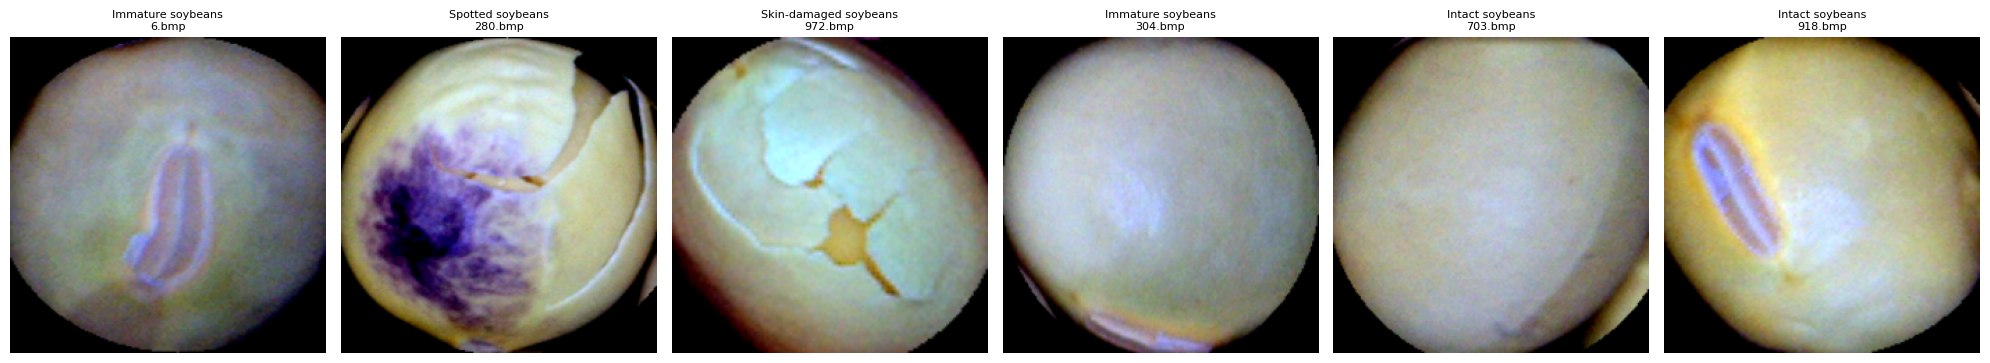

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct path identified in the previous cell
data_path = path
print(f"\n--- Displaying Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [4]:
!pip install split-folders

In [5]:
import splitfolders

# Define the output folder
output_folder = "soybean_split"

# Split with a ratio of 0.8 for train and 0.2 for val (test)
# seed=1337 ensures reproducibility
splitfolders.ratio(data_path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Dataset successfully split! Check the '{output_folder}' directory.")

Copying files: 5513 files [00:08, 615.55 files/s]

Dataset successfully split! Check the 'soybean_split' directory.


In [6]:
# Verify the split results
for split in ['train', 'val']:
    print(f"\n--- {split.upper()} set ---")
    split_path = os.path.join(output_folder, split)
    for class_name in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, class_name)))
        print(f"{class_name}: {count} images")


--- TRAIN set ---
Spotted soybeans: 846 images
Intact soybeans: 960 images
Immature soybeans: 900 images
Skin-damaged soybeans: 901 images
Broken soybeans: 801 images

--- VAL set ---
Spotted soybeans: 212 images
Intact soybeans: 241 images
Immature soybeans: 225 images
Skin-damaged soybeans: 226 images
Broken soybeans: 201 images


In [7]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cpu


In [8]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import time

# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(output_folder, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# Load a pretrained ResNet18 and reset final fully connected layer
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Training Loop
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f'Epoch {epoch}/{num_epochs - 1}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model_ft.train()
        else:
            model_ft.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer_ft.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model_ft(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer_ft.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


Epoch 0/9
----------
train Loss: 1.0210 Acc: 0.5910
val Loss: 0.4583 Acc: 0.8425
Epoch 1/9
----------
train Loss: 0.6099 Acc: 0.7736
val Loss: 0.3579 Acc: 0.8606
Epoch 2/9
----------
train Loss: 0.5263 Acc: 0.8088
val Loss: 0.3067 Acc: 0.8905
Epoch 3/9
----------
train Loss: 0.4775 Acc: 0.8283
val Loss: 0.2657 Acc: 0.9041
Epoch 4/9
----------
train Loss: 0.4390 Acc: 0.8421
val Loss: 0.2304 Acc: 0.9231
Epoch 5/9
----------
train Loss: 0.4118 Acc: 0.8478
val Loss: 0.2778 Acc: 0.8968
Epoch 6/9
----------
train Loss: 0.3917 Acc: 0.8571
val Loss: 0.2787 Acc: 0.9032
Epoch 7/9
----------
train Loss: 0.3789 Acc: 0.8634
val Loss: 0.2249 Acc: 0.9258
Epoch 8/9
----------
train Loss: 0.3803 Acc: 0.8605
val Loss: 0.2484 Acc: 0.9122
Epoch 9/9
----------
train Loss: 0.3397 Acc: 0.8768
val Loss: 0.2377 Acc: 0.9131


In [9]:
# Summarize Training Results
print("Training Summary")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")
print(f"Best Validation Accuracy: {max(history['val_acc']):.4f}")

Training Summary
Final Training Accuracy: 0.8768
Final Validation Accuracy: 0.9131
Best Validation Accuracy: 0.9258


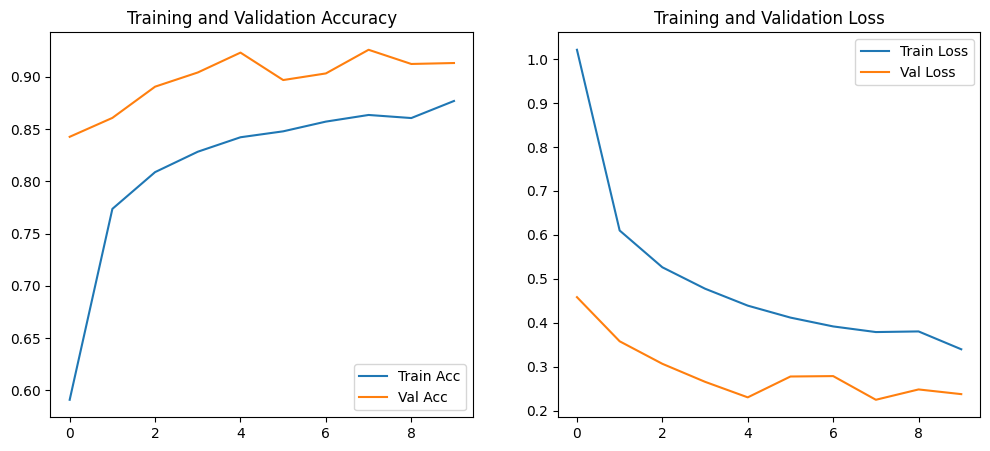

In [10]:
import matplotlib.pyplot as plt

# Plot Training and Validation Accuracy/Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()